# Turkish Morphology-Aware Retrieval - Baseline

Can Turkish embedding models tell apart sentences that differ only in a **suffix**
(`eve tasindim` vs `evden tasindim`)?

**Data** `morph_eval_set_v1.3.json` - 150 queries, 11 candidates each
(1 positive, 5 hard negatives, 5 easy negatives). Queries are natural everyday
recollections; the nominalised template mode was dropped in v1.0.

**Metrics**

| metric | meaning |
|---|---|
| Recall@1 | correct record ranked first |
| Recall@3 | correct record in the top 3 - a large @3-@1 gap means the gold is retrieved but out-ranked |
| Contrast Accuracy | positive scores above every single-suffix counterfactual. **This is the project's claim.** |
| Contrast Margin | cos(query, positive) - cos(query, counterfactual). Negative = the model prefers the wrong meaning |
| HardNeg@1 | share of top-1 hits that are hard negatives - tells us the errors are morphological, not topical |

## 1. Setup

In [1]:
!pip -q install sentence-transformers

import json, warnings
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sentence_transformers import SentenceTransformer

warnings.filterwarnings("ignore")
pd.set_option("display.width", 180)
pd.set_option("display.max_colwidth", 70)
print("cuda:", torch.cuda.is_available())

cuda: True


## 2. Data

In [2]:
EVAL_FILE = "morph_eval_set_v1.3.json"

try:
    DATA = json.load(open(EVAL_FILE, encoding="utf-8"))
except FileNotFoundError:
    from google.colab import files
    EVAL_FILE = list(files.upload().keys())[0]
    DATA = json.load(open(EVAL_FILE, encoding="utf-8"))

ITEMS = DATA["items"]
s = DATA["statistics"]
print(f"{DATA['dataset_name']} v{DATA['version']}  |  "
      f"{s['n_queries']} queries, {s['n_candidates']} candidates, "
      f"{s['n_phenomena']} phenomena")
print("tier :", s["by_tier"])
print("layer:", s["by_layer"])
print("slice:", s["by_slice"])

turkish_morph_retrieval_eval v1.3.0  |  150 queries, 1650 candidates, 73 phenomena
tier : {'standard': 90, 'hard': 40, 'minimal': 20}
layer: {'single': 99, 'chain': 51}
slice: {'core': 135, 'extended_hard': 15}


## 3. Evaluation

In [3]:
# E5 and Qwen3 are trained with instruction prefixes; the wrong prefix costs several points.
INSTRUCT = ("Instruct: Given a web search query, retrieve relevant passages that "
            "answer the query\nQuery: ")
MODEL_PROMPTS = {
    "e5-large":     ("query: ", "passage: "),
    "bge-m3":       ("", ""),
    "modernbert-tr": (INSTRUCT, ""),
    "qwen3-8b":     (INSTRUCT, ""),
}


def evaluate(model, name, items, batch_size=8):
    """Cosine-rank each 11-candidate pool and collect one row per query."""
    qp, dp = MODEL_PROMPTS.get(name, ("", ""))
    rows = []

    for it in items:
        cands = it["candidates"]
        embs = model.encode([qp + it["query"]] + [dp + c["text"] for c in cands],
                            normalize_embeddings=True, batch_size=batch_size)
        sims = embs[1:] @ embs[0]
        order = np.argsort(-sims)

        gold = next(i for i, c in enumerate(cands) if c["id"] == it["gold_id"])
        rank = int(np.where(order == gold)[0][0]) + 1
        gold_sim = float(sims[gold])

        # candidates that flip exactly one suffix relative to the positive
        mc = [float(sims[i]) for i, c in enumerate(cands)
              if c.get("subtype") == "morph_counterfactual"]

        top1, top2 = cands[order[0]], cands[order[1]]
        rows.append({
            "model": name, "query_id": it["query_id"], "query": it["query"],
            "tier": it["tier"], "layer": it["layer"], "slice": it.get("slice", "core"),
            "phenomenon": it["phenomenon"], "rank": rank,
            "recall@1": float(rank == 1), "recall@3": float(rank <= 3),
            "contrast_acc": float(all(gold_sim > m for m in mc)),
            "contrast_margin": gold_sim - max(mc),
            "hardneg@1": float(top1["role"] == "hard_negative"),
            "gold_text": cands[gold]["text"], "gold_sim": gold_sim,
            "top1_subtype": top1.get("subtype", ""), "top1_text": top1["text"],
            "top1_sim": float(sims[order[0]]),
            "top2_text": top2["text"], "top2_sim": float(sims[order[1]]),
        })

    return pd.DataFrame(rows)

## 4. Run

In [4]:
MODELS = [
    ("e5-large",     "intfloat/multilingual-e5-large",    {}),
    ("bge-m3",       "BAAI/bge-m3",                       {}),
    ("modernbert-tr", "ytu-ce-cosmos/modernbert-tr-embed", {}),
    ("qwen3-8b",     "Qwen/Qwen3-Embedding-8B",
     {"model_kwargs": {"torch_dtype": torch.float16}}),
]

frames = []
for name, repo, kw in MODELS:
    print(f"{name:14s} loading...", end=" ")
    model = SentenceTransformer(repo, trust_remote_code=True, **kw)
    try:
        model.default_prompt_name = None   # avoid double-applying our prefix
    except Exception:
        pass
    frames.append(evaluate(model, name, ITEMS))
    del model
    torch.cuda.empty_cache()
    print("done")

PQ = pd.concat(frames, ignore_index=True)

e5-large       loading... 

modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/160k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/690 [00:00<?, ?B/s]

...

merges.txt:   0%|          | 0.00/1.67M [00:00<?, ?B/s]

tokenizer.json: reconstructing file:   0%|          |  0.00B / 11.4MB            

tokenizer.json: downloading bytes:           |  0.00B            

config.json:   0%|          | 0.00/313 [00:00<?, ?B/s]

done


## 5. Results

In [5]:
METRICS = ["recall@1", "recall@3", "contrast_acc", "contrast_margin", "hardneg@1"]


def ci(v, n_boot=10000, seed=0):
    """Bootstrap over queries - embedding inference itself is deterministic."""
    rng = np.random.default_rng(seed)
    v = np.asarray(v)
    draws = rng.choice(v, size=(n_boot, len(v)), replace=True).mean(axis=1)
    return np.percentile(draws, 2.5), np.percentile(draws, 97.5)


summary = PQ.groupby("model")[METRICS].mean().sort_values("recall@1", ascending=False)
summary["R@3-R@1"] = summary["recall@3"] - summary["recall@1"]
summary["R@1 95% CI"] = [
    "[%.2f, %.2f]" % ci(PQ.loc[PQ.model == m, "recall@1"].values) for m in summary.index]
summary["CAcc 95% CI"] = [
    "[%.2f, %.2f]" % ci(PQ.loc[PQ.model == m, "contrast_acc"].values) for m in summary.index]

display(summary.round(3))
print(f"\n{len(ITEMS)} queries, 11 candidates - random baseline R@1 = 0.09, R@3 = 0.27")

,recall@1,recall@3,contrast_acc,contrast_margin,hardneg@1,R@3-R@1,R@1 95% CI,CAcc 95% CI
model,,,,,,,,
e5-large,0.447,0.867,0.720,0.013,0.553,0.420,"[0.37, 0.53]","[0.65, 0.79]"
qwen3-8b,0.447,0.833,0.660,0.022,0.553,0.387,"[0.37, 0.53]","[0.59, 0.73]"
bge-m3,0.360,0.833,0.640,0.029,0.633,0.473,"[0.29, 0.43]","[0.56, 0.71]"
modernbert-tr,0.307,0.740,0.507,0.003,0.693,0.433,"[0.23, 0.38]","[0.43, 0.59]"



150 queries, 11 candidates - random baseline R@1 = 0.09, R@3 = 0.27


## 6. Breakdown

In [6]:
for field in ["tier", "layer", "slice"]:
    print(f"--- {field} ---")
    display(PQ.pivot_table(index="model", columns=field,
                           values=["recall@1", "contrast_acc"], aggfunc="mean").round(2))

print("--- 10 weakest phenomena (mean over models) ---")
display(PQ.groupby("phenomenon")[["recall@1", "contrast_acc"]].mean()
          .sort_values("contrast_acc").head(10).round(2))

--- tier ---


contrast_acc                  recall@1                 
tier                  hard minimal standard     hard minimal standard
model                                                                
bge-m3                0.62    0.70     0.63     0.30    0.55     0.34
e5-large              0.70    0.70     0.73     0.48    0.55     0.41
modernbert-tr         0.52    0.85     0.42     0.22    0.55     0.29
qwen3-8b              0.70    0.80     0.61     0.45    0.50     0.43

--- layer ---


contrast_acc        recall@1       
layer                chain single    chain single
model                                            
bge-m3                0.61   0.66     0.37   0.35
e5-large              0.71   0.73     0.43   0.45
modernbert-tr         0.45   0.54     0.31   0.30
qwen3-8b              0.63   0.68     0.41   0.46

--- slice ---


contrast_acc               recall@1              
slice                 core extended_hard     core extended_hard
model                                                          
bge-m3                0.63          0.73     0.37          0.27
e5-large              0.72          0.73     0.48          0.13
modernbert-tr         0.48          0.73     0.29          0.47
qwen3-8b              0.66          0.67     0.47          0.20

--- 10 weakest phenomena (mean over models) ---


,recall@1,contrast_acc
phenomenon,,
adlastirma_iyelik,0.0,0.0
adlastirma_karsi_olgusal,0.0,0.0
ulac_olumsuzluk_cogul,0.0,0.0
ulac_ken_olumsuzluk,0.0,0.0
olumsuzluk_yeterlilik_kisi,0.0,0.0
kosul_yeterlilik_kisi,0.0,0.0
kip_istek_kisi,0.0,0.0
kanit_karsi_olgusal,0.0,0.0
ulac_sira_ettirgen,0.0,0.0


## 7. Chart

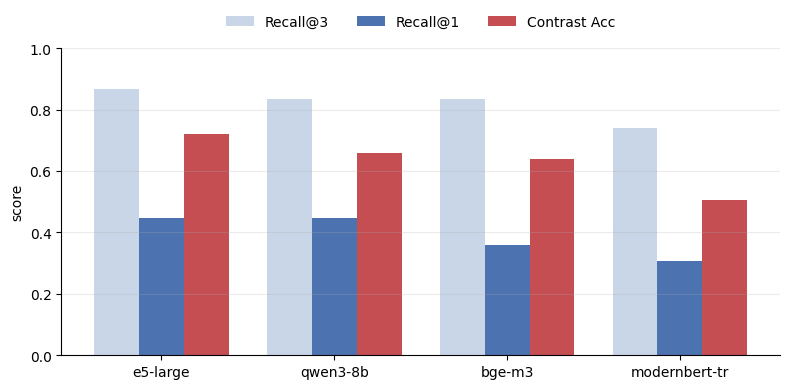

In [7]:
order = summary.index.tolist()
x = np.arange(len(order))

fig, ax = plt.subplots(figsize=(8, 4))
ax.bar(x - 0.26, summary.loc[order, "recall@3"], 0.26, label="Recall@3", color="#c9d6e8")
ax.bar(x,        summary.loc[order, "recall@1"], 0.26, label="Recall@1", color="#4c72b0")
ax.bar(x + 0.26, summary.loc[order, "contrast_acc"], 0.26, label="Contrast Acc", color="#c44e52")

ax.set_xticks(x)
ax.set_xticklabels(order)
ax.set_ylim(0, 1)
ax.set_ylabel("score")
ax.legend(frameon=False, ncol=3, loc="upper center", bbox_to_anchor=(0.5, 1.15))
for side in ("top", "right"):
    ax.spines[side].set_visible(False)
ax.grid(axis="y", alpha=0.25)
plt.tight_layout()
plt.show()

## 8. What went wrong

`delta` is how far the wrong candidate was ahead of the gold.

In [8]:
FOCUS = "e5-large"     # switch to inspect another model

errors = (PQ[(PQ.model == FOCUS) & (PQ["rank"] > 1)]
          .assign(delta=lambda d: d.top1_sim - d.gold_sim)
          [["query_id", "tier", "query", "gold_text", "gold_sim",
            "top1_subtype", "top1_text", "top1_sim", "delta"]]
          .sort_values("delta", ascending=False).round(3))

print(f"{FOCUS}: {len(errors)}/{len(ITEMS)} missed at rank 1")
print("error source:", errors.top1_subtype.value_counts().to_dict())
display(errors)

e5-large: 83/150 missed at rank 1
error source: {'same_feature_wrong_content': 37, 'state_variant': 25, 'morph_counterfactual': 16, 'partial_trap': 5}


,query_id,tier,query,gold_text,gold_sim,top1_subtype,top1_text,top1_sim,delta
73,q74_ability3,standard,O gün bavulu tek başıma kaldırabilmiştim.,Bavul ağırdı ama kimseden yardım almadan yerden kaldırmayı başardım.,0.873,same_feature_wrong_content,O gün dolabı tek başıma kaldırabilmiştim.,0.936,0.063
124,q125_manner_nominal,hard,"Onun ne söylediğini değil, söyleyişini eleştirmiştim.","İçerikle bir sorunum yoktu; rahatsız olduğum şey üslubuydu, yani i...",0.893,same_feature_wrong_content,"Onun ne yazdığını değil, yazışını eleştirmiştim.",0.947,0.054
144,q145_cond_abil_person,hard,Sen yardım edebilseydin işi birlikte bitirebilirdik.,Senin destek vermen mümkün olmadı; verebilseydin işi ikimiz tamaml...,0.901,morph_counterfactual,Ben yardım edebilseydim işi birlikte bitirebilirdik.,0.954,0.053
142,q143_pass_caus_tense,hard,Bahçe duvarı bana sorulmadan yıktırılmıştı.,"Duvarın yıkımı için birine iş verilmiş, benim onayım alınmamıştı; ...",0.869,same_feature_wrong_content,Garaj duvarı bana sorulmadan yıktırılmıştı; bahçeye dokunulmadı.,0.921,0.051
79,q80_passive3,standard,O toplantı benim haberim olmadan iptal edilmişti.,Toplantının iptalini ben yapmadım; karar başkası tarafından alınmı...,0.875,same_feature_wrong_content,O eğitim benim haberim olmadan iptal edilmişti.,0.923,0.048
...,...,...,...,...,...,...,...,...,...
105,q106_scope_caus_abil_neg,hard,Belgeyi kimseye imzalatamadığım için işlem tamamlanmamıştı.,İmza için birkaç kişiye ulaşmaya çalıştım ama hiçbirine belgeyi im...,0.905,state_variant,Belgeyi imzalatamayan ben değil asistanımdı; o birkaç kişiye ulaşt...,0.907,0.002
30,q31_case_source_goal2,standard,Zeynep o gün kurstan çıkıp kütüphaneye geçmişti.,Zeynep ders bitiminde kurs binasını bırakıp kütüphaneye vardı.,0.919,morph_counterfactual,Zeynep kütüphaneden çıkıp kursa geçti.,0.921,0.001
36,q37_person2,standard,Otel rezervasyonunu bizzat ben yapmıştım.,Oteldeki rezervasyonu ben yapmıştım; onay e-postası da benim adres...,0.912,partial_trap,Oteldeki rezervasyonu benim adıma asistanım yapmıştı.,0.913,0.001
109,q110_contrastive_focus,hard,"Onun gitmemesini değil, geç kalmasını sorun etmiştim.",Asıl rahatsız olduğum şey gecikmesiydi; katılmaması zaten benim iç...,0.899,same_feature_wrong_content,"Onun konuşmamasını değil, sesini yükseltmesini sorun etmiştim.",0.900,0.001


## 9. What went right - and how narrowly

`margin` is the gap to the runner-up. A small margin means a correct answer that a
slightly different phrasing would have flipped.

In [9]:
correct = (PQ[(PQ.model == FOCUS) & (PQ["rank"] == 1)]
           .assign(margin=lambda d: d.top1_sim - d.top2_sim)
           [["query_id", "tier", "query", "gold_sim", "top2_text", "top2_sim",
             "margin", "contrast_margin"]]
           .sort_values("margin").round(3))

print(f"{FOCUS}: {len(correct)} correct, most fragile first")
display(correct.head(20))

e5-large: 67 correct, most fragile first


,query_id,tier,query,gold_sim,top2_text,top2_sim,margin,contrast_margin
38,q39_caus2,standard,Ceketteki yırtığı kendi elimle dikmiştim.,0.904,Pantolonumdaki yırtığı iğne iplikle kendim diktim.,0.903,0.000,0.031
57,q58_privative,standard,Kahvemi o gün şekersiz içmiştim.,0.926,O gün çayımı şekersiz içtim; kahve içmedim.,0.926,0.000,0.023
112,q113_min_person_number,minimal,O evi ben tek başıma satın almıştım.,0.876,O evi 2019'da ailem aldı; ben yalnızca oraya taşındım.,0.876,0.000,0.012
63,q64_plural,standard,Hafta sonu kuzenlerimin hepsi bize gelmişti.,0.933,Hafta sonu komşularımın hepsi bize geldi.,0.932,0.000,0.022
126,q127_third_person_request,standard,"Dosyayı Kerem'in göndermesini istemiştim, kendim göndermedim.",0.933,Kerem'den dosyayı göndermesini isteyecektim ama vakit kalmayınca k...,0.932,0.001,0.007
68,q69_without,standard,O sabah kahvaltı etmeden evden çıkmıştım.,0.930,O sabah duş almadan evden çıkmıştım.,0.928,0.001,0.005
58,q59_min_privative,minimal,O akşam çorbamı tuzsuz içmiştim.,0.904,Öğlen sofrada çorbamı tuzsuz içtim; yanına da bir dilim ekmek aldım.,0.902,0.002,0.016
97,q98_min_plural,minimal,Hafta sonu sinemaya birkaç arkadaşımla birlikte gitmiştim.,0.929,Hafta sonu arkadaşımla sinemaya gittim; film epey uzundu.,0.927,0.002,0.002
95,q96_min_converb,minimal,Raporu toplantıya girmeden önce okumuştum.,0.925,Toplantıdan önce raporu okuyacaktım; notlarımı da kenara alacaktım.,0.923,0.002,0.039
87,q88_pass_ability_neg,hard,"O dosya bir türlü açılamamıştı, bozuk çıkmıştı.",0.916,"O bağlantı bir türlü açılamamıştı, sayfa bozuktu.",0.913,0.003,0.038


## 10. Negative margins

Queries where the model scored the single-suffix counterfactual **above** the correct
record. Not uncertainty - an active preference for the opposite meaning. This is the
cleanest evidence for the paper.

In [10]:
neg = (PQ[PQ.contrast_margin < 0][["model", "query_id", "tier", "query", "contrast_margin"]]
       .sort_values("contrast_margin").round(3))

print(f"{len(neg)} (model, query) pairs with a negative contrast margin")
print("by model:", neg.model.value_counts().to_dict())
print("by tier :", neg.tier.value_counts().to_dict())

n_models = PQ.model.nunique()
universal = neg.groupby("query_id").size().pipe(lambda s: s[s == n_models]).index
print(f"\nAll {n_models} models fail on {len(universal)} queries:")
for q in universal:
    print("  ", q, "|", PQ.loc[PQ.query_id == q, "query"].iloc[0])

220 (model, query) pairs with a negative contrast margin
by model: {'modernbert-tr': 74, 'bge-m3': 54, 'qwen3-8b': 50, 'e5-large': 42}
by tier : {'standard': 144, 'hard': 57, 'minimal': 19}

All 4 models fail on 23 queries:
   q105_dilution_aspect | Sen geldiğinde ben o kitabı çoktan bitirmiştim.
   q108_evid_counterfactual | Haberi zamanında duymuş olsaydım o kararı vermezdim.
   q134_ability5 | Salonu tek başıma toplayabilmiştim.
   q137_person4 | Hesabı o akşam ben ödemiştim.
   q138_possessive4 | O bisiklet benim değil, kardeşimindi.
   q142_conditional3 | Hava düzelirse maça gideceğimizi söylemiştik.
   q145_cond_abil_person | Sen yardım edebilseydin işi birlikte bitirebilirdik.
   q146_converb_neg_plural | Belgeleri kontrol etmeden göndermiştim.
   q147_nom_case_counterfactual | Onun gelmesini beklemeseydim işi çoktan bitirmiş olurdum.
   q31_case_source_goal2 | Zeynep o gün kurstan çıkıp kütüphaneye geçmişti.
   q53_min_poss | Arabayı pazar günü kendi ellerimle yıkamıştım.
   q5

## 11. Export

In [11]:
PQ.to_csv("per_query_results.csv", index=False)
summary.to_csv("summary.csv")
print("saved: per_query_results.csv, summary.csv")

saved: per_query_results.csv, summary.csv
